In [1]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using:", device)

Using: mps


In [2]:
import os

os.environ["HF_HOME"] = "models"

In [3]:
from transformers import GPT2Model, GPT2Tokenizer

model_name = "gpt2"
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2Model.from_pretrained(
    model_name,
    output_hidden_states=True
)

model = model.to(device)
model.eval()
tokenizer.pad_token = tokenizer.eos_token

print("Hidden size:", model.config.n_embd)
print("Layers:", model.config.n_layer)

/Users/armaanjagirdar/Projects/SAE_GPT2/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 8039.96it/s]


Hidden size: 768
Layers: 12


In [4]:
from datasets import load_dataset

dataset = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="train")
texts = [
    x["text"]
    for x in dataset
    if len(x["text"].strip()) > 50
]
texts = texts[:5000]

print("Examples:", len(texts))
print(texts[0])

Examples: 5000
 Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first game and follows the " Nameless " , a penal military unit serving the nation of Gallia during the Second Europan War who perform secret black operations and are pitted against the Imperial unit " Calamaty Raven " . 



In [5]:
LAYER = 6
MAX_LENGTH = 128
BATCH_SIZE = 16

In [6]:
from tqdm.auto import tqdm

activations = []

with torch.no_grad():
    for i in tqdm(range(0, len(texts), BATCH_SIZE)):
        batch_texts = texts[i:i + BATCH_SIZE]

        tokens = tokenizer(
            batch_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH
        )

        input_ids = tokens["input_ids"].to(device)
        attention_mask = tokens["attention_mask"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        hidden = outputs.hidden_states[LAYER]
        mask = attention_mask.bool()

        batch_activations = hidden[mask]

        activations.append(
            batch_activations.detach().cpu()
        )

activations = torch.cat(activations)
print("Activation shape:", activations.shape)

100%|██████████| 313/313 [01:05<00:00,  4.80it/s]


Activation shape: torch.Size([507227, 768])


In [7]:
mean = activations.mean(dim=0, keepdim=True)
std = activations.std(dim=0, keepdim=True) + 1e-6

activations = (activations - mean) / std
print(activations.mean().item(), activations.std().item())

-4.024822697346053e-09 0.9999985098838806


In [8]:
import torch.nn as nn
import torch.nn.functional as F

class SparseAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()

        self.encoder = nn.Linear(input_dim, latent_dim)
        self.decoder = nn.Linear(latent_dim, input_dim)

    def encode(self, x):
        return F.relu(self.encoder(x))

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        z = self.encode(x)
        x_hat = self.decode(z)

        return x_hat, z

In [9]:
INPUT_DIM = activations.shape[1]
LATENT_DIM = 2048

torch.manual_seed(42)
sae = SparseAutoencoder(input_dim=INPUT_DIM, latent_dim=LATENT_DIM).to(device)

print(sae)


SparseAutoencoder(
  (encoder): Linear(in_features=768, out_features=2048, bias=True)
  (decoder): Linear(in_features=2048, out_features=768, bias=True)
)


In [10]:
optimizer = torch.optim.Adam(sae.parameters(),lr=1e-3)

In [11]:
SPARSITY_COEFF = 3e-3
BATCH_SIZE = 512
EPOCHS = 5

for epoch in range(EPOCHS):
    permutation = torch.randperm(len(activations))

    total_loss = 0
    total_recon = 0
    total_sparse = 0

    for i in tqdm(range(0, len(activations), BATCH_SIZE), desc=f"Epoch {epoch + 1}/{EPOCHS}"):
        indices = permutation[i:i + BATCH_SIZE]
        
        x = activations[indices].to(device)
        x_hat, z = sae(x)
        reconstruction_loss = F.mse_loss(x_hat, x)

        sparsity_loss = z.sum(dim=-1).mean()
        loss = (
            reconstruction_loss
            + SPARSITY_COEFF * sparsity_loss
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            sae.decoder.weight.data = F.normalize(sae.decoder.weight.data, dim=0)

        total_loss += loss.item()
        total_recon += reconstruction_loss.item()
        total_sparse += sparsity_loss.item()

    n_batches = (len(activations) + BATCH_SIZE - 1) // BATCH_SIZE

    print(
        f"loss={total_loss/n_batches:.5f} | "
        f"recon={total_recon/n_batches:.5f} | "
        f"sparse={total_sparse/n_batches:.5f}"
    )

Epoch 1/5: 100%|██████████| 991/991 [00:15<00:00, 62.40it/s]


loss=0.64658 | recon=0.37962 | sparse=88.98871


Epoch 2/5: 100%|██████████| 991/991 [00:13<00:00, 75.42it/s] 


loss=0.46859 | recon=0.26432 | sparse=68.08781


Epoch 3/5: 100%|██████████| 991/991 [00:14<00:00, 66.18it/s] 


loss=0.43893 | recon=0.24720 | sparse=63.90904


Epoch 4/5: 100%|██████████| 991/991 [00:13<00:00, 71.83it/s]


loss=0.42448 | recon=0.24221 | sparse=60.75682


Epoch 5/5: 100%|██████████| 991/991 [00:13<00:00, 71.98it/s]

loss=0.41579 | recon=0.24108 | sparse=58.23881


In [12]:
with torch.no_grad():
    sample = activations[:5000].to(device)
    _, z = sae(sample)
    active_fraction = (z > 0).float().mean()

print(f"Fraction of active features: {active_fraction.item():.4%}"
)

Fraction of active features: 3.1632%


In [16]:
FEATURE_ID = 100

feature_activations = []

with torch.no_grad():
    for i in range(0, len(activations), BATCH_SIZE):
        batch = activations[i:i+BATCH_SIZE].to(device)
        _, z = sae(batch)
        feature_activations.append(z[:, FEATURE_ID].cpu())

feature_activations = torch.cat(feature_activations)
print(feature_activations.max().item())

6.5402398109436035


In [19]:
top_k = 10

values, indices = torch.topk(
    feature_activations,
    k=top_k
)

print("Top activations:")

for rank, (value, idx) in enumerate(zip(values, indices)):
    print(f"{rank + 1:2d}. Activation={value.item():.3f}")

Top activations:
 1. Activation=6.540
 2. Activation=6.495
 3. Activation=6.482
 4. Activation=6.451
 5. Activation=6.414
 6. Activation=6.256
 7. Activation=6.227
 8. Activation=6.224
 9. Activation=6.142
10. Activation=6.141


In [20]:
with torch.no_grad():
    sample = activations[:2000].to(device)
    reconstructed, _ = sae(sample)
    mse = F.mse_loss(reconstructed, sample)

print("Reconstruction MSE:", mse.item())

Reconstruction MSE: 0.2547289729118347


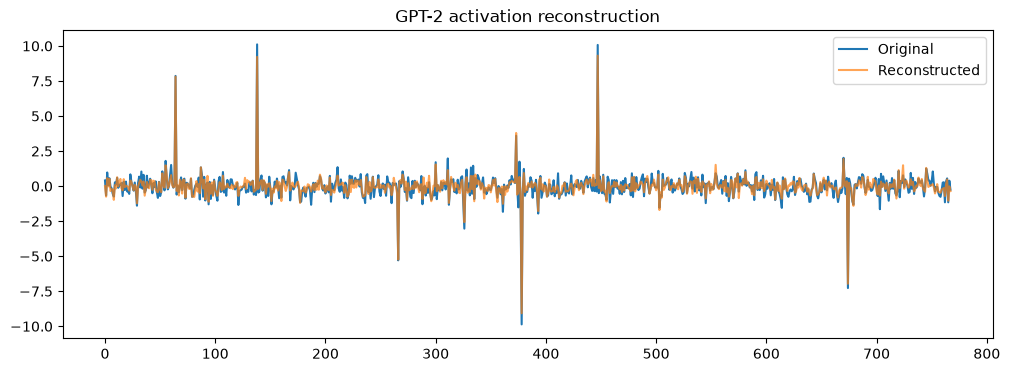

In [21]:
import matplotlib.pyplot as plt

idx = 0
original = sample[idx].cpu()
reconstructed = reconstructed[idx].cpu()

plt.figure(figsize=(12, 4))

plt.plot(original.numpy(), label="Original")
plt.plot(reconstructed.numpy(), label="Reconstructed", alpha=0.7)

plt.legend()
plt.title("GPT-2 activation reconstruction")
plt.show()